# **Adding external variables to our model(SARIMAX model)**

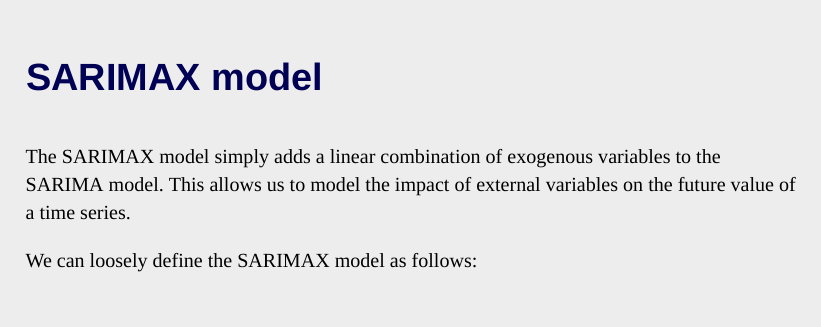
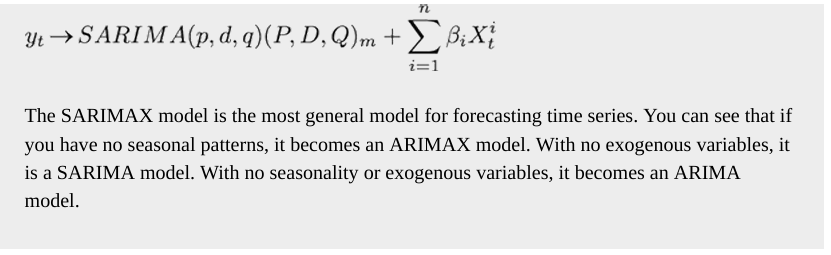

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## **Exploring the exogenous variables of the US macroeconomics dataset**

**Let’s load the US macroeconomics dataset and explore the different
exogenous variables available to us to forecast the real GDP. This dataset is
available with the statsmodels library, meaning that you do not need to
download and read an external file. You can load the dataset using the
datasets module of statsmodels.**

In [3]:
import statsmodels.api as sm

macro_econ_data=sm.datasets.macrodata.load_pandas().data
macro_econ_data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


### ***visualizing realgdp***

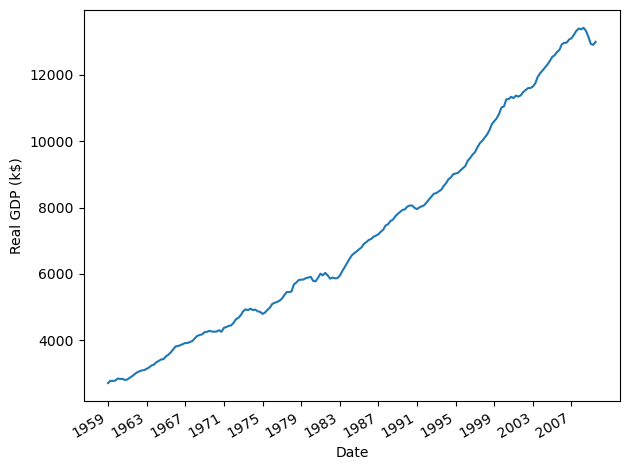

In [4]:
fig, ax=plt.subplots()

ax.plot(macro_econ_data['realgdp'])
ax.set_xlabel('Date')
ax.set_ylabel('Real GDP (k$)')

plt.xticks(np.arange(0,208,16),np.arange(1959,2010,4))

fig.autofmt_xdate()
plt.tight_layout()

*This displays the entire DataFrame containing the US macroeconomics
dataset. Table 9.1 describes the meaning of each variable. We have our target
variable, or endogenous variable, which is the real GDP. Then we have 11
exogenous variables that can be used for forecasting, such as personal and
federal consumption expenditures, interest rate, inflation rate, population,
and others.*

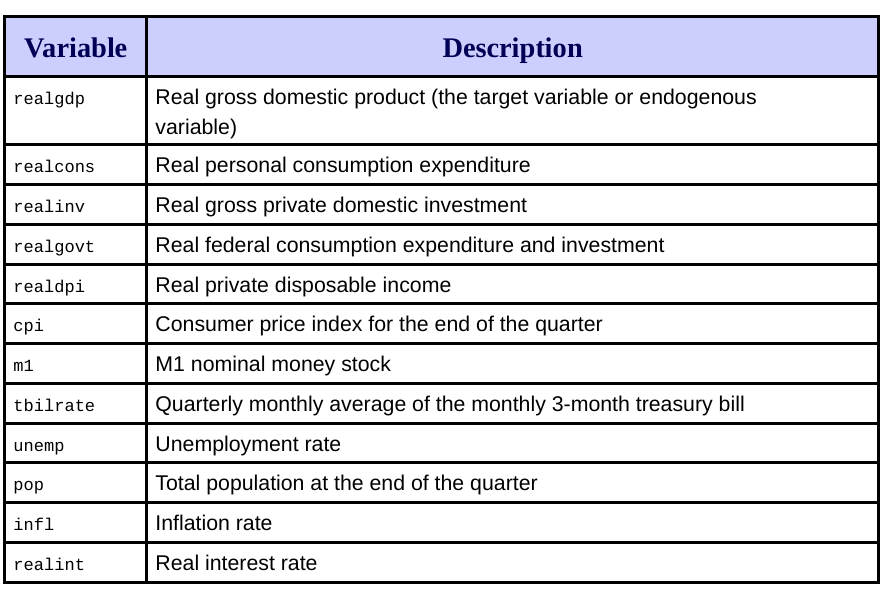

**For the sake of simplicity and clarity, we will only work with six variables**

### **We can visualize how each variable behaves through time to see if we can discern any distinctive patterns**

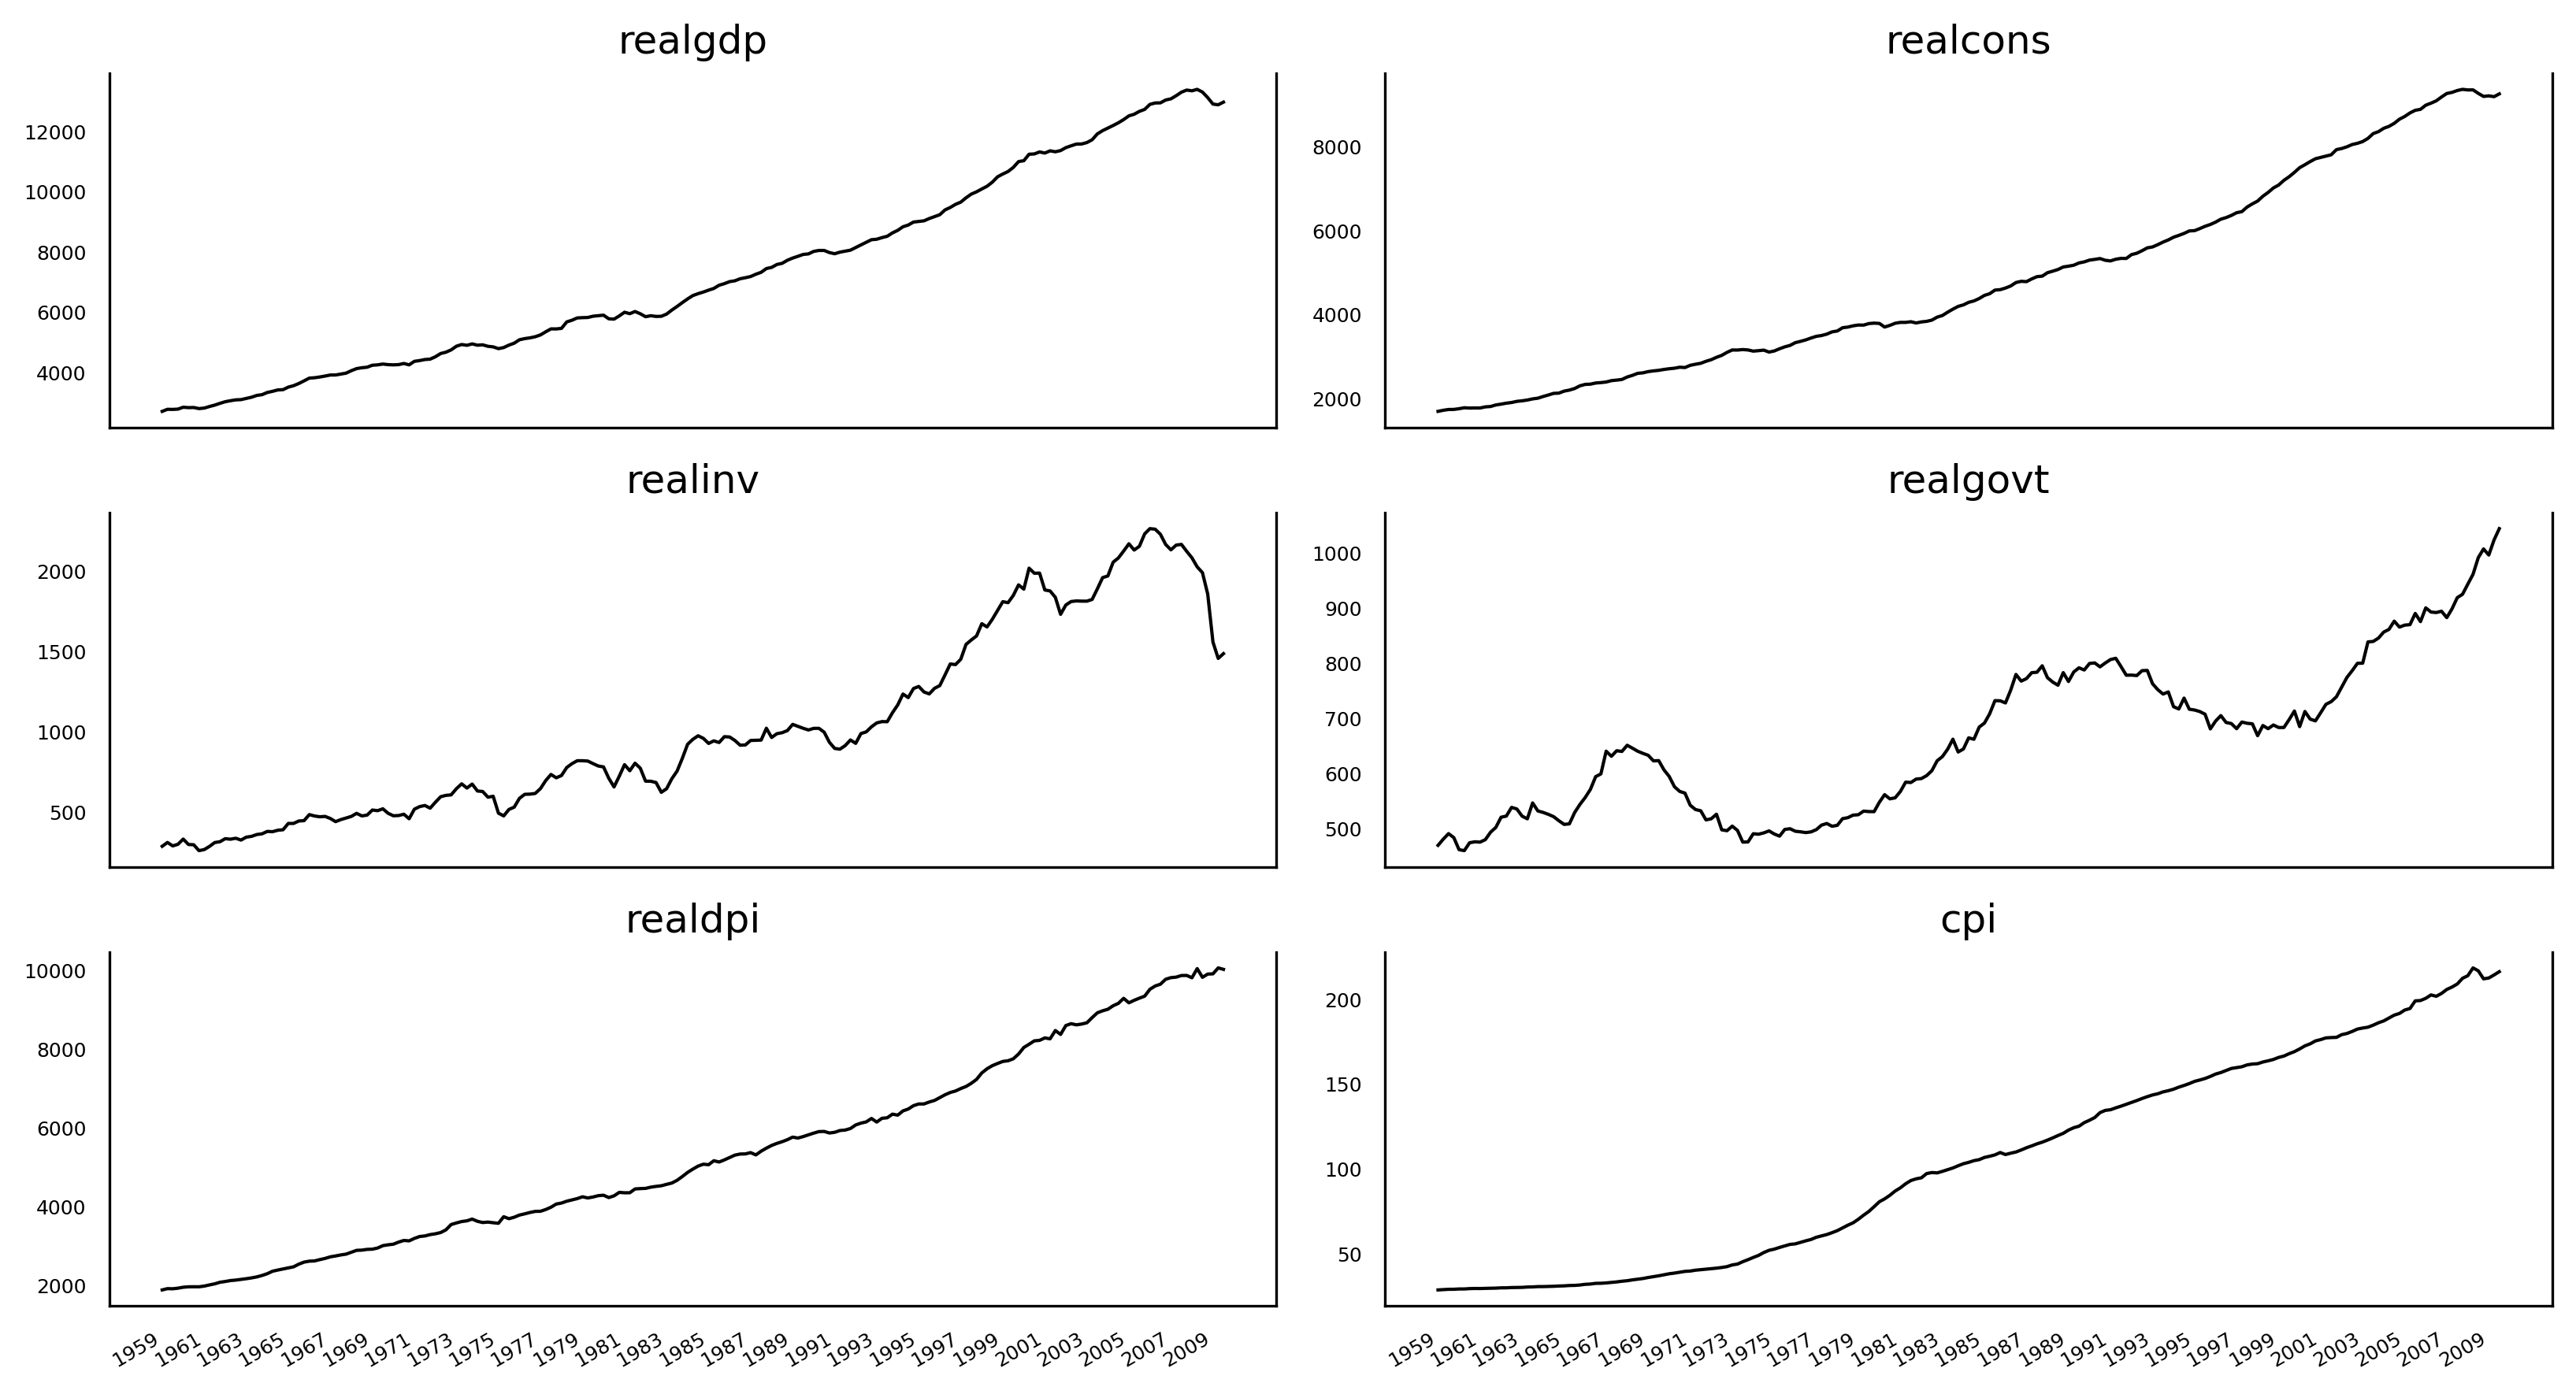

In [5]:
fig, axes = plt.subplots(nrows=3, ncols=2, dpi=300, figsize=(11,6))

for i, ax in enumerate(axes.flatten()[:6]):
    data = macro_econ_data[macro_econ_data.columns[i+2]]
    
    ax.plot(data, color='black', linewidth=1)
    ax.set_title(macro_econ_data.columns[i+2])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.setp(axes, xticks=np.arange(0, 208, 8), xticklabels=np.arange(1959, 2010, 2))
fig.autofmt_xdate()
plt.tight_layout()

**Evolution of the real GDP and five exogenous variables from
1959 to 2009. You’ll notice that realgdp, realcons, realdpi, and cpi
all have a similar shape, which means that realcons, realdpi, and cpi
are potentially good predictors, although a graphical analysis is not
sufficient to confirm that idea. On the other hand, realgovt has peaks
and troughs that do not appear in realgdp, so we can hypothesize that
realgovt is a weaker predictor.**

There are two ways to work with exogenous variables for time series
forecasting. First, we could train multiple models with various combinations
of exogenous variables, and see which model generates the best forecasts.
Alternatively, we can simply include all exogenous variables and stick to
model selection using the AIC, as we know this yields a good-fitting model
that does not overfit.

### -------------------------------------------------------------------------------------------------------------------

Why Disregard the p-value in Regression Analysis?
The core confusion:
Most people see a high p-value for a predictor and think "this variable is useless, remove it." That is wrong in the context of forecasting.
What p-value actually tests:
The p-value only answers one question: Is this coefficient significantly different from zero?

If p < 0.05, the coefficient is statistically significant (not zero)
If p > 0.05, we cannot confidently say it is non-zero
That is all it tells you. It says nothing about whether the variable actually improves your forecast.

Why it is misused:
People confuse two different questions:

"Is this predictor correlated with the target?" — answered by p-value
"Does this predictor improve forecasting?" — answered by AIC, RMSE, out-of-sample testing
These are not the same question.

The right approach — use AIC:
AIC (Akaike Information Criterion) balances model fit vs complexity. When you minimize AIC, it automatically handles which predictors to keep. You do not need to manually remove variables based on p-values.
Practical takeaway for SARIMAX:
When you run .summary() on your SARIMAX model and see high p-values for your exogenous variables, do not remove them based on that alone. Instead, compare models using AIC and out-of-sample forecast accuracy (RMSE/MAE) to decide what stays.

### ------------------------------------------------------------------------------------------------------------------

## ***Forecasting the real GDP using the SARIMAX model***

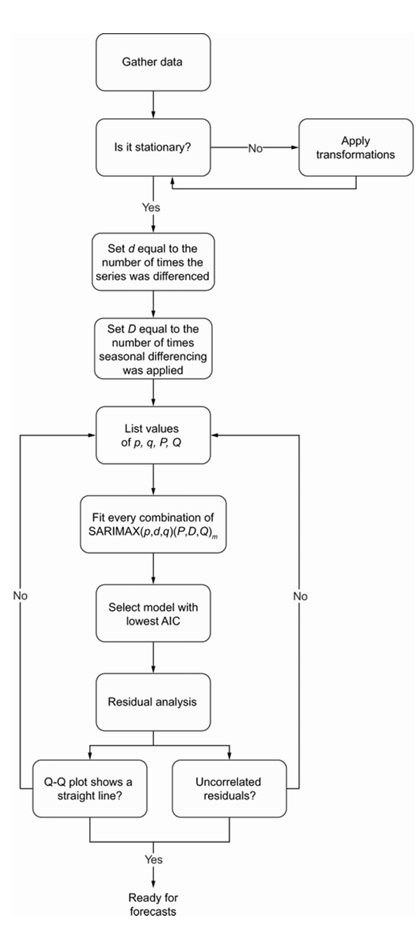

**General modeling procedure for the SARIMAX model. This
procedure can be applied to any problems, as the SARIMAX model is
the most general forecasting model and can accommodate all the
different processes and properties of time series that we have explored.
Notice that the only change here is that we are fitting a SARIMAX
model instead of a SARIMA model as we did in chapter 8. The rest of
the procedure remains the same.**

### -----we’ll first check for the stationarity of our target using the augmented Dickey-Fuller (ADF) test.-----

In [6]:
target = macro_econ_data['realgdp']
exog = macro_econ_data[['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi']]

ad_fuller_result = adfuller(target)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 1.7504627967647104
p-value: 0.9982455372335032


**This returns an ADF statistic of 1.75 and a p-value of 1.00. Since the ADF
statistic is not a large negative number, and the p-value is larger than 0.05,
we cannot reject the null hypothesis and conclude that the series is not
stationary.**

In [7]:
target_diff = target.diff()

ad_fuller_result = adfuller(target_diff[1:])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -6.305695561658104
p-value: 3.327882187668259e-08


**This now returns an ADF statistic of –6.31 and p-value of 3.32 × 10–8. With
a large negative ADF statistic and a p-value smaller than 0.05, we can reject
the null hypothesis and conclude that the series is now stationary. Therefore,
we know that d = 1. Since we did not need to take a seasonal difference to
make the series stationary, D = 0.**

### -----We will now define the optimize_SARIMAX function, which will fit all unique combinations of the model and return a DataFrame in ascending order of AIC.-----

In [8]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df


In [9]:
p = range(0, 4, 1)
d = 1
q = range(0, 4, 1)
P = range(0, 4, 1)
D = 0
Q = range(0, 4, 1)
s = 4

parameters = product(p, q, P, Q)
parameters_list = list(parameters)

In [10]:
target_train = target[:200]
exog_train = exog[:200]

result_df = optimize_SARIMAX(target_train, exog_train, parameters_list, d, D, s)
result_df

  0%|          | 0/256 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(3, 3, 0, 0)",1742.832118
1,"(3, 3, 1, 0)",1744.967745
2,"(3, 3, 0, 1)",1744.997729
3,"(2, 2, 0, 0)",1745.485041
4,"(2, 2, 0, 1)",1746.151353
...,...,...
251,"(0, 2, 0, 0)",1761.579044
252,"(0, 3, 0, 0)",1762.317095
253,"(0, 0, 0, 0)",1764.754980
254,"(1, 0, 0, 0)",1765.379412


**Now we can fit the selected model and display a summary table to see the coefficients associated with our exogenous**

In [11]:
best_model = SARIMAX(target_train, exog_train, order=(3,1,3), seasonal_order=(0,0,0,4), simple_differencing=False)
best_model_fit = best_model.fit(disp=False)

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                realgdp   No. Observations:                  200
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -859.416
Date:                Mon, 25 May 2026   AIC                           1742.832
Time:                        11:06:10   BIC                           1782.352
Sample:                             0   HQIC                          1758.827
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9670      0.045     21.618      0.000       0.879       1.055
realinv        1.0136      0.033     30.849      0.000       0.949       1.078
realgovt       0.7284      0.127      5.740      0.0

**Summary table of the selected model. You can see that our
exogenous variables were assigned coefficients. You can also see their p
values under the column P>|z|**

*you’ll notice that all exogenous variables have a p-value
smaller than 0.05, except for realdpi, which has a p-value of 0.712. This
means that the coefficient of realdpi is not significantly different from 0.
You’ll also notice that its coefficient is 0.0091. However, the coefficient is
kept in the model, as the p-value does not determine the relevance of this
predictor in forecasting our target*

### -----Moving on with the modeling procedure, we’ll now study the residuals of the model-----

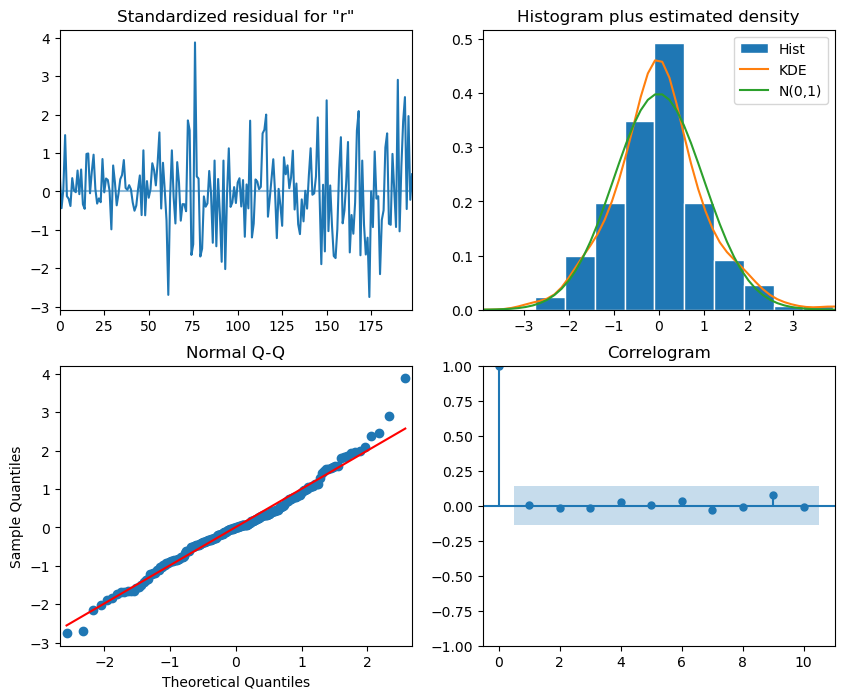

In [12]:
best_model_fit.plot_diagnostics(figsize=(10,8));

**Residual analysis of the selected model. You can see that the
residuals have no trend and a fairly constant variance over time, just
like white noise. In the top-right plot, the distribution of residuals is
very close to a normal distribution. This is further supported by the Q
Q plot at the bottom left, which shows a fairly straight line that lies on y
= x. Finally, the correlogram shows no significant coefficients after lag 0,
just like white noise. Therefore, from a graphical analysis, the residuals
of this model resemble white noise.**

### -----Now we’ll apply the Ljung-Box test to make sure the residuals are not correlated-----

In [14]:
residuals = best_model_fit.resid 
  
acorr_ljungbox(residuals, np.arange(1, 11, 1)) 

,lb_stat,lb_pvalue
1,0.082130,0.774432
2,0.209835,0.900399
3,0.214578,0.975202
4,1.190007,0.879741
5,1.191958,0.945647
6,1.211933,0.976291
7,1.411555,0.985215
8,1.422502,0.993921
9,1.794344,0.994318
10,1.799255,0.997660


**All the p-values are greater than 0.05. Therefore, we do not reject the null
hypothesis, and we conclude that the residuals are independent and
uncorrelated. Having passed both residual checks, our model can be used for
forecasting.**

## **Function to forecast the next timestep multiple times**

In [15]:
def recursive_forecast(endog: Union[pd.Series, list], exog: Union[pd.Series, list], train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = endog[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'SARIMAX':
        pred_SARIMAX = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(endog[:i], exog[:i], order=(3,1,3), seasonal_order=(0,0,0,4), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(exog=exog)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMAX.extend(oos_pred)
            
        return pred_SARIMAX

**The recursive_forecast function allows us to predict the next timestep
over a certain period of time. Specifically, we will use it to forecast the next
timestep starting in 2008 and going to the third quarter of 2009.**

In [16]:
target_train = target[:196]
target_test = target[196:]

pred_df = pd.DataFrame({'actual': target_test})

TRAIN_LEN = len(target_train)
HORIZON = len(target_test)
WINDOW = 1

pred_last_value = recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_SARIMAX = recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'SARIMAX')

pred_df['pred_last_value'] = pred_last_value
pred_df['pred_SARIMAX'] = pred_SARIMAX

pred_df

,actual,pred_last_value,pred_SARIMAX
196,13366.865,13391.249,13344.062967
197,13415.266,13366.865,13373.514605
198,13324.600,13415.266,13378.802524
199,13141.920,13324.600,13327.729611
200,12925.410,13141.920,13133.740145
201,12901.504,12925.410,12887.479517
202,12990.341,12901.504,12873.798354


**With the predictions done, we can visualize which model has the lowest
mean absolute percentage error (MAPE)**

In [17]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [18]:
mape_last = mape(pred_df.actual, pred_df.pred_last_value)
mape_SARIMAX = mape(pred_df.actual, pred_df.pred_SARIMAX)

print(mape_last, mape_SARIMAX)

0.736849498653785 0.7028720676668045


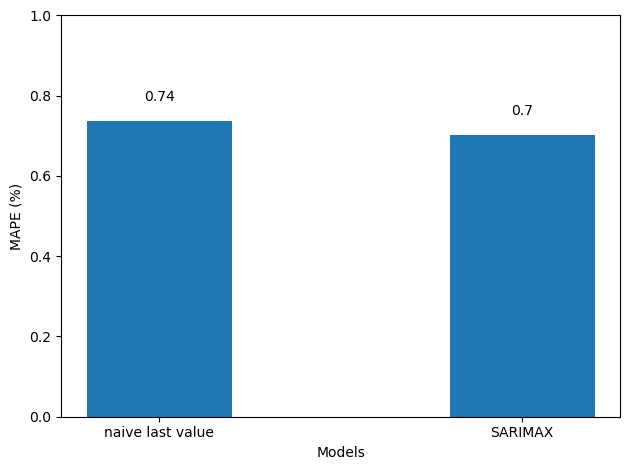

In [19]:
fig, ax = plt.subplots()

x = ['naive last value', 'SARIMAX']
y = [mape_last, mape_SARIMAX]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 1)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 0.05, s=str(round(value,2)), ha='center')

plt.tight_layout()

### **The mean absolute percentage error (MAPE) of the forecasts of each method. You can see that the SARIMAX model only has a slightly smaller MAPE than the baseline. This highlights the importance of using a baseline, as a MAPE of 0.70% is extremely good, but a naive forecast achieves a MAPE of 0.74%, meaning that the SARIMAX model only has a small advantage.**